# VGG Feature Extraction
A more sophisticated method to do clustering of in-plane images is to extract features using convlutional neural networks.

To extract features, we will download the pre-trained VGG model, take the feature layer, average pooling layer, and one fully-connected layer that outputs a 4096-dimensional vector. 

Reference: Simonyan, K., & Zisserman, A. (2015). Very Deep Convolutional Networks for Large-Scale Image Recognition. ArXiv:1409.1556 [Cs]. http://arxiv.org/abs/1409.1556


In [1]:
%load_ext autoreload
%autoreload 2
import os
import re
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import anise.image_utils as image_utils
import anise.utils as utils

from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN


In [11]:
import torch
from torch import optim, nn
from torchvision import models, transforms
from tqdm import tqdm
from torchvision.transforms import v2

class FeatureExtractor(nn.Module):
    def __init__(self, model):
        super(FeatureExtractor, self).__init__()
        # Extract VGG-16 Feature Layers
        self.features = list(model.features)
        self.features = nn.Sequential(*self.features)
        # Extract VGG-16 Average Pooling Layer
        self.pooling = model.avgpool
        # Convert the image into one-dimensional vector
        self.flatten = nn.Flatten()
        # Extract the first part of fully-connected layer from VGG16
        self.fc = model.classifier[0]

    def forward(self, x):
        # It will take the input 'x' until it returns the feature vector called
        out = self.features(x)
        out = self.pooling(out)
        out = self.flatten(out)
        out = self.fc(out)
        return out


def VGG_extract_features(fusi_data, model, device): 

    if fusi_data.ndim == 4: # if the data is 4D, take the first channel elevation = 0
        fusi_data = fusi_data[:,0]

    #  Transform the image, so it becomes readable with the model
    transform = v2.Compose([
        v2.ToImage(),
        v2.Resize((448, 448)),
        v2.Grayscale(num_output_channels=3),
        v2.ToDtype(torch.float32, scale=True),
    ])

    # Will contain the feature
    features = []
    # Iterate each image
    for i in tqdm(range(fusi_data.shape[-1])):
        # Read the file
        img = fusi_data[..., i]
        # Transform the image
        img = transform(img)
        # Reshape the image. PyTorch model reads 4-dimensional tensor
        # [batch_size, channels, width, height]
        img = img.reshape(1, 3, 448, 448)
        img = img.to(device)
        # We only extract features, so we don't need gradient
        with torch.no_grad():
            # Extract the feature from the image
            feature = model(img)
        # Convert to NumPy Array, Reshape it, and save it to features variable
        features.append(feature.cpu().detach().numpy().reshape(-1))
    # Convert to NumPy Array
    features = np.array(features)
    return features

# Load NIFTI

In [4]:
#################################################################
#      Define data paths and choose output path location        #
#################################################################

# If NIFTI has not been parsed in to fUSI_BIDS format, use the following line on terminal to parse data:
# ```python fUSI_to_BIDS_session.py /2024-06-13/UCLA_006/ --root /cassini/UCLA_collaboration```

base_path = Path.home() / 'Downloads/UCLA_fUSI_BIDS/sourcedata/sub-UCLA_006/ses-2024-06-13'

run = 8
    
run_folder = f'run-{run:02d}'

# Get the registration and GLM output directories
register_dir, glm_dir = utils.get_BIDS_derivative_dir(base_path)
plot_dir = register_dir / 'plots' / run_folder
plot_dir.mkdir(parents=True, exist_ok=True)

# find filenames that match with the run
filenames = utils.get_run_files_from_BIDS(base_path, run)

print('Select the first file to load')
filename = filenames[0]

print(f'\nLoaded NIFTI file: {filename}')
nifti_data, metadata, events = utils.load_data_from_BIDS(base_path, filename)
fusi_data = nifti_data.get_fdata()
n_frames = fusi_data.shape[-1]
filename = filename.replace('.nii.gz', '')
acq_tag = filename[re.search(run_folder, filename).end()+1:-4]

Found 1 files:
	 sub-UCLA_006_task-audio_tone_run-08_acq-0_proc-pca_60_pwdt.nii.gz
Select the first file to load

Loaded NIFTI file: sub-UCLA_006_task-audio_tone_run-08_acq-0_proc-pca_60_pwdt.nii.gz

Loaded NIFTI file: sub-UCLA_006_task-audio_tone_run-08_acq-0_proc-pca_60_pwdt.nii.gz
Loaded json: 	   sub-UCLA_006_task-audio_tone_run-08_acq-0_proc-pca_60_pwdt.json
Loaded events: 	   sub-UCLA_006_task-audio_tone_run-08_acq-0_proc-pca_60_events.tsv


# Apply VGG pretrain model, then PCA and DBSCAN

In [13]:
# Initialize the model
model = models.vgg16(weights='DEFAULT')
new_model = FeatureExtractor(model)
# Change the device to GPU if available
device = torch.device('cuda:0' if torch.cuda.is_available() else "cpu")
features = VGG_extract_features(fusi_data, new_model.to(device), device)

In [ ]:
# normalize the data
features_norm = (features - features.mean(axis=0)) / features.std(axis=0)

pca_n_components = 2
pca=PCA(n_components=pca_n_components)

# Reduce number of dimension
lowd = pca.fit_transform(features_norm)
lowd = lowd / lowd.std(axis=0)


In [ ]:
from sklearn.cluster import DBSCAN

eps = .8 # smaller eps, more clusters
db = DBSCAN(eps=eps).fit(lowd)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)
print(labels)

Estimated number of clusters: 1
Estimated number of noise points: 5
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0
  0  0  0 -1  0  0  0  0  0  0 -1 -1  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]


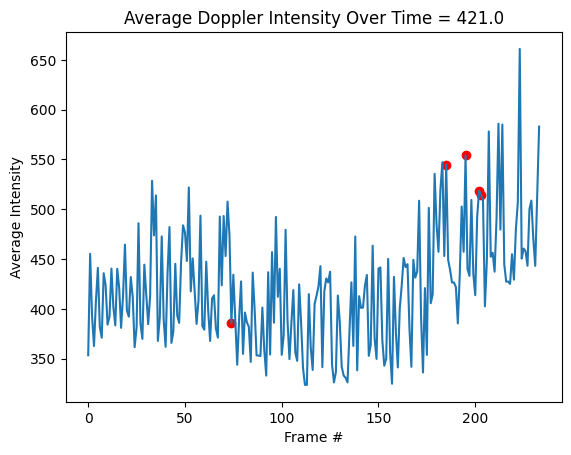

In [ ]:
################################################
#     Display Doppler intensity time course    #
################################################

# find and confirm if there's any outlier frames that should be removed e.g. high brightness or noise
doppler_intensity = np.mean(fusi_data, axis=tuple(range(0, fusi_data.ndim - 1)))
plt.plot(doppler_intensity)
plt.title(f'Average Doppler Intensity Over Time = {doppler_intensity.mean().round()}')
plt.xlabel('Frame #')
plt.ylabel('Average Intensity')
loc = np.where(labels != 0)[0]
plt.scatter(loc, doppler_intensity[loc], c='r')

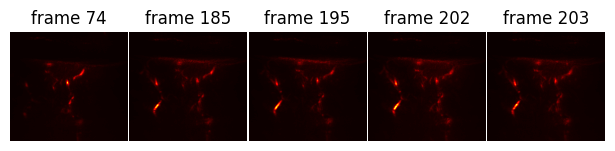

<Figure size 640x480 with 0 Axes>

In [ ]:
# display outliers frames
if np.any(labels != 0):
    image_utils.show_imgs(fusi_data[:,0], np.where(labels != 0)[0])
plt.savefig(plot_dir / (acq_tag+'outlier_images.png'), dpi=300, bbox_inches='tight')

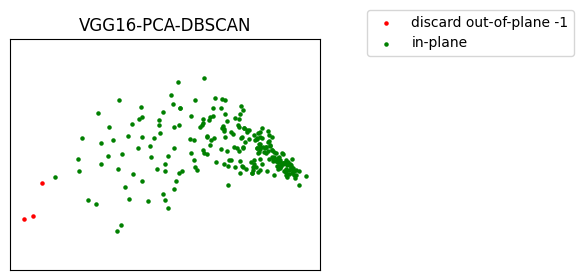

In [ ]:
fig = image_utils.plot_embedding(lowd, labels, 'VGG16-PCA-DBSCAN')
fig.savefig(plot_dir / (acq_tag+'VGG16-PCA-DBSCAN.png'), dpi=300, bbox_inches='tight')